# Random Forest — Who Survived the Titanic?

A single **Decision Tree** is easy to read but fragile — grow it fully and it memorizes the training data (overfits). A **Random Forest** fixes this with a simple idea: **grow many different trees and let them vote.**

What makes the trees *different* from each other?
- **Bagging** — each tree is trained on a random sample of the rows (drawn with replacement).
- **Random features** — at each split, a tree may only choose from a random subset of the columns.

Because each tree makes *different* mistakes, their errors tend to cancel out when they vote — so the forest is usually **more accurate** and **more stable** than any single tree. It's the wisdom of the crowd, for trees. 🌲🌲🌲

We'll use the famous **Titanic** dataset and predict who survived, in three steps:
1. Train a single **Decision Tree**.
2. Train a **Random Forest** and compare.
3. Try the forest with a **different number of trees** (`n_estimators`).

In [1]:
import pandas as pd

df = pd.read_csv('titanic.csv')
print('rows, columns:', df.shape)
df.head()

rows, columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### What the columns mean

- `Survived` — **our target**: `1` = survived, `0` = did not
- `Pclass` — ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) — a proxy for wealth
- `Sex`, `Age` — passenger sex and age
- `SibSp` — number of siblings / spouses aboard
- `Parch` — number of parents / children aboard
- `Fare` — ticket fare paid
- `Embarked` — port boarded (C = Cherbourg, Q = Queenstown, S = Southampton)
- `PassengerId`, `Name`, `Ticket`, `Cabin` — identifiers / mostly-missing columns we'll drop

## Cleaning & preprocessing

Titanic needs a little more prep than our earlier datasets. Three steps:

1. **Drop columns** that don't help: `PassengerId`, `Name`, `Ticket` (identifiers) and `Cabin` (mostly missing).
2. **Fill missing values**: `Age` (177 blanks) with the median, `Embarked` (2 blanks) with the most common port.
3. **Encode text columns as numbers**: models need numbers, so we turn `Sex` and `Embarked` into 0/1 columns with `pd.get_dummies`.

> No scaling needed — tree-based models split on thresholds, so the scale of a column doesn't matter.

In [2]:
# 1. drop unhelpful columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# 2. fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. turn text columns into numeric 0/1 columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print('missing values left:', df.isnull().sum().sum())
df.head()

missing values left: 0


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


`Sex_male` is 1 for men, 0 for women; `Embarked_Q` / `Embarked_S` flag the boarding port. Now everything is numeric.

## Features, target, and train / test split

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Survived')
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2
)
print('train:', X_train.shape[0], ' test:', X_test.shape[0])

train: 712  test: 179


## Step 1 — A single Decision Tree

Let's start with one fully-grown decision tree as our baseline. We'll print its **train** and **test** accuracy (to spot overfitting) and the classification report.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

print('Decision Tree — train accuracy:', round(tree.score(X_train, y_train), 3))
print('Decision Tree — test accuracy: ', round(tree.score(X_test, y_test), 3))
print(classification_report(y_test, tree.predict(X_test),
                            target_names=['died', 'survived']))

Decision Tree — train accuracy: 0.985
Decision Tree — test accuracy:  0.76
              precision    recall  f1-score   support

        died       0.80      0.82      0.81       110
    survived       0.70      0.67      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



Look at the gap: **train accuracy ~0.98 but test accuracy only ~0.76**. The tree memorized the training passengers but generalizes poorly — the classic decision-tree overfitting. Let's see if a forest does better.

## Step 2 — A Random Forest

`RandomForestClassifier` trains a whole ensemble of trees (100 by default) and has them vote. Same fit / predict interface as before.

In [5]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

print('Random Forest — train accuracy:', round(forest.score(X_train, y_train), 3))
print('Random Forest — test accuracy: ', round(forest.score(X_test, y_test), 3))
print(classification_report(y_test, forest.predict(X_test),
                            target_names=['died', 'survived']))

Random Forest — train accuracy: 0.985
Random Forest — test accuracy:  0.816
              precision    recall  f1-score   support

        died       0.83      0.88      0.85       110
    survived       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



The forest's **test accuracy (~0.82) clearly beats the single tree (~0.76)** — even though its training accuracy is just as high. That's the ensemble effect: 100 trees, each trained on different random slices of the data, vote together and cancel out one another's mistakes. Same idea as asking a whole crowd instead of one person.

## Step 3 — How many trees? The `n_estimators` knob

`n_estimators` is the number of trees in the forest. Let's train it a couple more times with different values and compare the test accuracy directly.

In [6]:
for n in [10, 100]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    print(f'{n:>3} trees  ->  test accuracy = {rf.score(X_test, y_test):.3f}')

 10 trees  ->  test accuracy = 0.821


100 trees  ->  test accuracy = 0.816


Both forests land in the **low 0.82s** — comfortably above the single tree's 0.76, and close to each other. A handful of trees already captures most of the benefit; adding more mainly makes the result *steadier* rather than dramatically more accurate.

The practical rule: **more trees never hurt accuracy**, they just cost more compute time. Pick enough to be stable (100 is a fine default) and stop.

## Bonus — which features mattered?

A forest averages feature importance across all its trees, giving a more reliable ranking than any single tree. So *what* decided who survived?

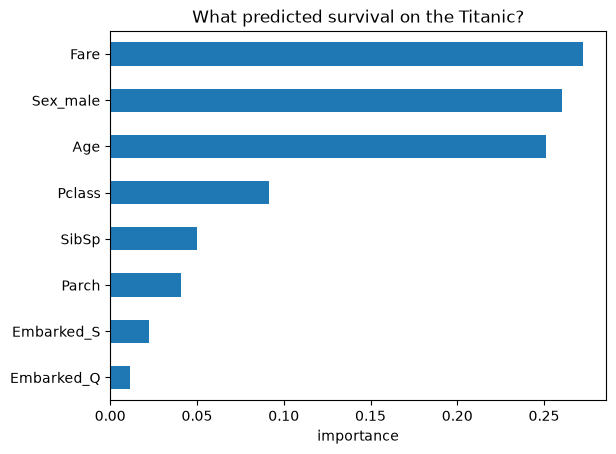

In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values()

importances.plot(kind='barh')
plt.xlabel('importance')
plt.title('What predicted survival on the Titanic?')
plt.show()

The top factors are **`Fare`, `Sex`, and `Age`** — matching the grim history of "women and children first," and that wealthier passengers (higher fare / 1st class) were more likely to reach a lifeboat.

## What we learned

| | **Decision Tree** | **Random Forest** |
|---|---|---|
| How it works | one tree of yes/no splits | many trees vote |
| Overfitting | high (memorizes training data) | **much lower** (averaging cancels errors) |
| Test accuracy here | ~0.76 | **~0.82** |
| Interpretability | **very easy** (draw the tree) | harder (100 trees), but gives feature importances |

**Takeaways:**
- A Random Forest = **many varied decision trees voting**; it keeps the tree's perks (no scaling, handles non-linearity) while **curing most of its overfitting**.
- Here the forest lifted test accuracy from ~0.76 to ~0.82 over the single tree.
- **More trees** improve stability then plateau; 100 is a sensible default.

**Try next:** tune `max_depth` or `max_features` to squeeze out a bit more performance.